# Assignment 1
Authors: Kevin Havis & Aali John-Harry

## Introduction

As a "beachhead" project, we decided to create a small network to represent the major U.S. cities we have collectively been to. We were interested to see if we could connect our own local networks, despite our differences in geographical location.

For this graph, our nodes are major U.S. cities, and the edges represent the major highways that connect them.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Specify typing to guide collaboration
CityNodes = list[tuple[str, dict[str]]]

# Specify variables to distinguish nodes
kevin_color = "#4A90D9"
aali_color = "#E06C75"
common_color = "#8B5CC4"

## Data Setup

Firstly, we will list out the major cities we've each been to. These will be our **nodes**.We'll set this up as a list at first to make it easier to write, since we're doing this by hand. Our **edges** in this case are simplified geographic "connections", which could represent abstracted interstate highways.

Secondly, we will create a structure to index the cities turn them into proper node structures, complete with `name` and `color` labels.

We will use the `color` label to help distinguish each individual's nodes, as well as a common color to highlight any overlap.

In [19]:
# Write out list of cities
# Easiest to write out in east-to-west
kevin_cities = [
    "New York, NY",
    "Boston, MA",
    "Hartford, CT",
    "Albany, NY",
    "Buffalo, NY",
    "Columbus, OH",
    "Cleveland, OH",
    "Toledo, OH",
    "St. Joseph, MI",
    "Madison, WI",
    "New Orleans, LA",
    "Las Vegas, NV",
    "Los Angeles, CA",
]

In [ ]:
# Create edges between cities (by index)
kevin_edges = [
    ("0", "3"),  # New York <-> Albany
    ("0", "4"),  # New York <-> Buffalo
    ("3", "4"),  # Albany <-> Buffalo
    ("5", "6"),  # Columbus <-> Cleveland
    ("5", "7"),  # Columbus <-> Toledo
    ("6", "7"),  # Cleveland <-> Toledo
    ("1", "2"),  # Boston <-> Hartford
    ("2", "0"),  # Hartford <-> New York
    ("4", "6"),  # Buffalo <-> Cleveland
    ("7", "8"),  # Toledo <-> St. Joseph
    ("8", "9"),  # St. Joseph<-> Madison
    ("10", "5"),  # New Orleans<-> Columbus
    ("11", "12"),  # Las Vegas <-> Los Angeles
    ("4", "10"),  # Buffalo <-> New Orleans
    ("4", "11"),  # Buffalo <-> Las Vegas
]

In [20]:
aali_cities = []

In [ ]:
def create_nodes(cities: list, color: str):
    "Enrich a city list with colors to distinguish"

    nodes = []
    for i, city in enumerate(cities):
        node = (str(i), {"name": city, "color": color})
        nodes.append(node)

    return nodes


# Create the nodes
kevin_nodes = create_nodes(cities=kevin_cities, color=kevin_color)
aali_nodes = create_nodes(cities=aali_cities, color=aali_color)

In [ ]:
def color_common_nodes(nodes_1, nodes_2, common_color):
    "Update the color for nodes that appear in both lists"
    "Mutates in place"
    # Find common cities
    common = {c for c, _ in nodes_1} & {c for c, _ in nodes_2}

    # Update their colors
    for city, attrs in nodes_1 + nodes_2:
        if city in common:
            attrs["color"] = common_color

    # Return none - we mutate in place
    return None


# Update common cities with common color

color_common_nodes(
    nodes_1=kevin_nodes,
    nodes_2=aali_nodes,
    common_color=common_color,
)

## Create the Network

We can now create the network using `networkx` library. To do this, we can use two simple methods; `add_nodes_from()` and `add_edges_from()` respectively.

We'll then draw the graph with `matplotlib` using city names as node labels and colors as mentioned previously.

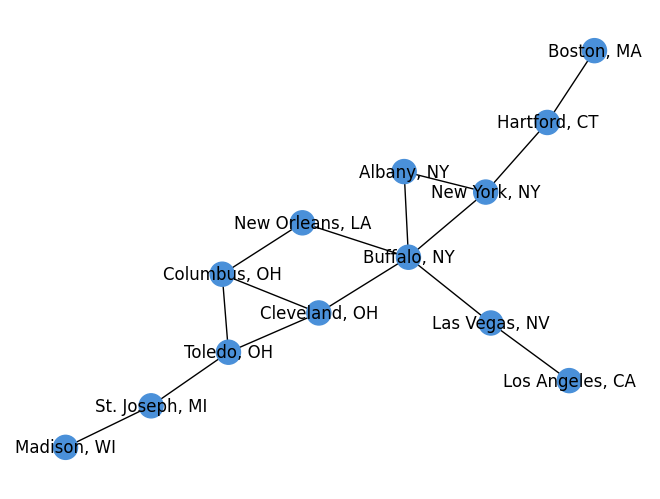

In [ ]:
# Initialize the graph, then add nodes, edges
G = nx.Graph()
G.add_nodes_from(kevin_nodes)
G.add_edges_from(kevin_edges)

# Specify the labels
labels = nx.get_node_attributes(G, "name")
colors = [G.nodes[n]["color"] for n in G.nodes]

# Draw the network
positions = nx.kamada_kawai_layout(G)
nx.draw(G, pos=positions, labels=labels, node_color=colors, with_labels=True)

plt.show()

## Conclusion

With NetworkX, it is simple to create an intitial network graph that using native Python data structures. Adding metadata to the graph allows for interesting observations, and plotting helps with intuiting the patterns the network holds.